In [1]:
import os
import cv2
import numpy as np # linear algebra
import pandas as pd #
import matplotlib.pyplot as plt 
import seaborn as sns
from keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization, GlobalAveragePooling2D, Input, Activation
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing import image
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

In [2]:
train_data_gen = ImageDataGenerator(rescale=1./255)
validation_data_gen = ImageDataGenerator(rescale=1./255)

# Preprocess all train images
train_generator = train_data_gen.flow_from_directory(
        'D:/Kuliah Files/Semester 7/Machine Learning/Emotion_detection_CNN/data/train',
        target_size=(48, 48),
        batch_size=64,
        color_mode="grayscale",
        class_mode="categorical",
        shuffle=True)

# Preprocess all test images
validation_generator = validation_data_gen.flow_from_directory(
        'D:/Kuliah Files/Semester 7/Machine Learning/Emotion_detection_CNN/data/test',
        target_size=(48, 48),
        batch_size=64,
        color_mode="grayscale",
        class_mode="categorical",
        shuffle=False)

Found 29200 images belonging to 7 classes.
Found 7300 images belonging to 7 classes.


In [3]:
emotion_model = Sequential()

# Input layer
emotion_model.add(Conv2D(64, kernel_size=(3,3), padding= 'same', input_shape=(48, 48, 1)))
emotion_model.add(BatchNormalization())
emotion_model.add(Activation('relu'))
emotion_model.add(MaxPooling2D(pool_size=(2,2)))
emotion_model.add(Dropout(0.25))

# Hidden layer 1
emotion_model.add(Conv2D(128, kernel_size=(5,5), padding= 'same'))
emotion_model.add(BatchNormalization())
emotion_model.add(Activation('relu'))
emotion_model.add(MaxPooling2D(pool_size=(2, 2)))
emotion_model.add(Dropout(0.25))

# Hidden layer 2
emotion_model.add(Conv2D(512, kernel_size=(3, 3), padding= 'same'))
emotion_model.add(BatchNormalization())
emotion_model.add(Activation('relu'))
emotion_model.add(MaxPooling2D(pool_size=(2, 2)))
emotion_model.add(Dropout(0.25))

# Hidden layer 3
emotion_model.add(Conv2D(512, kernel_size=(3, 3), padding= 'same'))
emotion_model.add(BatchNormalization())
emotion_model.add(Activation('relu'))
emotion_model.add(MaxPooling2D(pool_size=(2, 2)))
emotion_model.add(Dropout(0.25))

# Flatten Layer
emotion_model.add(Flatten())

# Fully Connected layer
emotion_model.add(Dense(256))
emotion_model.add(BatchNormalization())
emotion_model.add(Activation('relu'))
emotion_model.add(Dropout(0.25))

# Fully Connected layer
emotion_model.add(Dense(512))
emotion_model.add(BatchNormalization())
emotion_model.add(Activation('relu'))
emotion_model.add(Dropout(0.25))

emotion_model.add(Dense(7, activation='softmax'))

cv2.ocl.setUseOpenCL(False)

emotion_model.compile(loss='categorical_crossentropy', 
                        optimizer=Adam(learning_rate=0.0001), 
                        metrics=['accuracy'])
emotion_model.summary()


C:\Users\acer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,02

 Total params: 4,478,727 (17.08 MB)

 Trainable params: 4,474,759 (17.07 MB)

 Non-trainable params: 3,968 (15.50 KB)

In [4]:
emotion_model_info = emotion_model.fit (
        train_generator,
        steps_per_epoch=train_generator.n//64,
        epochs=100,
        validation_data=validation_generator,
        validation_steps=validation_generator.n//64)

Epoch 1/100


C:\Users\acer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


456/456 ━━━━━━━━━━━━━━━━━━━━ 878s 2s/step - accuracy: 0.2026 - loss: 2.1478 - val_accuracy: 0.2701 - val_loss: 1.9364
Epoch 2/100
  1/456 ━━━━━━━━━━━━━━━━━━━━ 14:13 2s/step - accuracy: 0.2969 - loss: 1.9281

C:\Users\acer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


456/456 ━━━━━━━━━━━━━━━━━━━━ 71s 151ms/step - accuracy: 0.2969 - loss: 1.9281 - val_accuracy: 0.2706 - val_loss: 1.9342
Epoch 3/100
456/456 ━━━━━━━━━━━━━━━━━━━━ 932s 2s/step - accuracy: 0.2828 - loss: 1.8724 - val_accuracy: 0.3387 - val_loss: 1.7296
Epoch 4/100
456/456 ━━━━━━━━━━━━━━━━━━━━ 59s 126ms/step - accuracy: 0.3125 - loss: 1.8075 - val_accuracy: 0.3391 - val_loss: 1.7284
Epoch 5/100
456/456 ━━━━━━━━━━━━━━━━━━━━ 938s 2s/step - accuracy: 0.3321 - loss: 1.7396 - val_accuracy: 0.3660 - val_loss: 1.6593
Epoch 6/100
456/456 ━━━━━━━━━━━━━━━━━━━━ 65s 139ms/step - accuracy: 0.3594 - loss: 1.7862 - val_accuracy: 0.3655 - val_loss: 1.6609
Epoch 7/100
456/456 ━━━━━━━━━━━━━━━━━━━━ 963s 2s/step - accuracy: 0.3697 - loss: 1.6432 - val_accuracy: 0.3805 - val_loss: 1.7047
Epoch 8/100
456/456 ━━━━━━━━━━━━━━━━━━━━ 63s 134ms/step - accuracy: 0.3750 - loss: 1.6814 - val_accuracy: 0.3817 - val_loss: 1.6990
Epoch 9/100
456/456 ━━━━━━━━━━━━━━━━━━━━ 981s 2s/step - accuracy: 0.4085 - loss: 1.5641 - val_

In [5]:
# save model structure in jason file
model_json = emotion_model.to_json()
with open("emotion_model.json", "w") as json_file:
    json_file.write(model_json)

emotion_model.save_weights('.weights.h5')

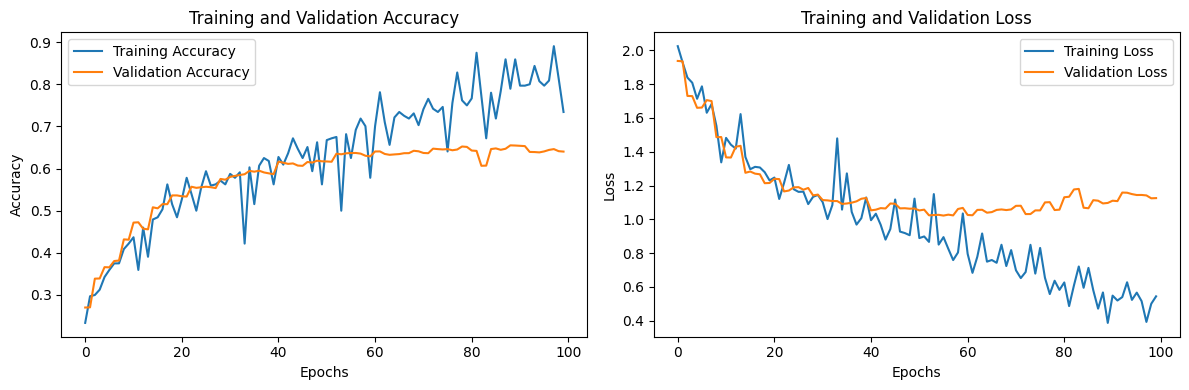

In [6]:
history = emotion_model_info.history

plt.figure(figsize=(12, 4))
# Plotting accuracy
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plotting loss
plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

115/115 ━━━━━━━━━━━━━━━━━━━━ 54s 459ms/step


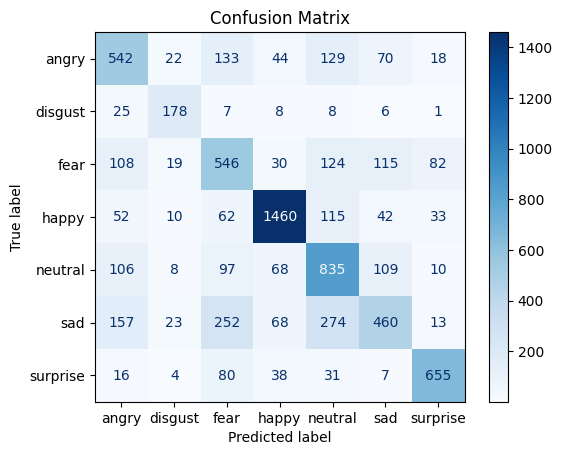

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Mengambil prediksi dari model
validation_generator.reset()  # Reset generator untuk memastikan urutan yang benar
predictions = emotion_model.predict(validation_generator)
predicted_classes = np.argmax(predictions, axis=1)

# Mengambil label sebenarnya
true_classes = validation_generator.classes
class_labels = list(validation_generator.class_indices.keys())  # Mendapatkan nama kelas

# Menghitung confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Menampilkan confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

(48, 48)


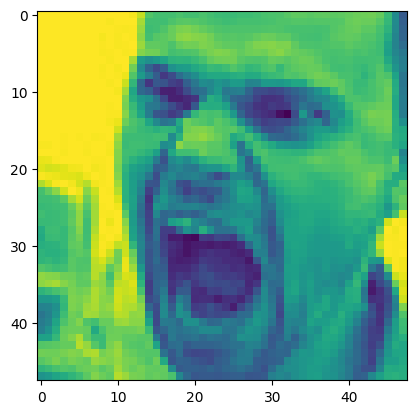

In [35]:
label_dict = {0: "Angry", 1: "Disgusted", 2: "Fearful", 3: "Happy", 4: "Neutral", 5: "Sad", 6: "Surprised"}
img = image.load_img("D:/Kuliah Files/Semester 7/Machine Learning/Emotion_detection_CNN/data/test/Angry/PrivateTest_1221822.jpg",target_size = (48,48),color_mode = "grayscale")
img = np.array(img)
plt.imshow(img)
print(img.shape)

In [36]:
mg = np.expand_dims(img,axis = 0) #makes image shape (1,48,48)
img = img.reshape(1,48,48,1)
result = emotion_model.predict(img)
result = list(result[0])
print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
[np.float32(1.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0)]


In [37]:
img_index = result.index(max(result))
print(label_dict[img_index])
plt.show()

Angry
